# Model: Multinomial Naive Bayes (TF-IDF)

> Add blockquote



## Shared Setup


In [ ]:
!pip install -q datasets scikit-learn pandas matplotlib seaborn

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import GridSearchCV, cross_validate, StratifiedKFold
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                              classification_report, confusion_matrix, ConfusionMatrixDisplay)

sns.set_style("whitegrid")

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

ds = load_dataset("cornell-movie-review-data/rotten_tomatoes")
train_df = ds["train"].to_pandas()
val_df = ds["validation"].to_pandas()
test_df = ds["test"].to_pandas()

for df in (train_df, val_df, test_df):
    df["clean_text"] = df["text"].apply(clean_text)

print("Train:", train_df.shape, "| Validation:", val_df.shape, "| Test:", test_df.shape)

Train: (8530, 3) | Validation: (1066, 3) | Test: (1066, 3)


## 1. Model Suitability

## 2. Implementation

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer

X_train_text, y_train = train_df["clean_text"], train_df["label"]
X_val_text,   y_val   = val_df["clean_text"],   val_df["label"]
X_test_text,  y_test  = test_df["clean_text"],  test_df["label"]

# Baseline: default settings, before any tuning
baseline = Pipeline([
    ("vec", TfidfVectorizer(ngram_range=(1, 1))),
    ("clf", MultinomialNB()),
])
baseline.fit(X_train_text, y_train)
print(f"Baseline (default settings) validation accuracy: "
      f"{accuracy_score(y_val, baseline.predict(X_val_text)):.4f}")

Baseline (default settings) validation accuracy: 0.7786


## 3. Hyperparameter Tuning Across Varieties



In [ ]:
pipe = Pipeline([
    ("vec", TfidfVectorizer()),
    ("clf", MultinomialNB()),
])

param_grid = {
    "vec": [TfidfVectorizer(), CountVectorizer()],
    "vec__min_df": [5, 10, 15],             # Increased min_df to drop rare/memorized tokens
    "vec__ngram_range": [(1, 1), (1, 2)],
    "clf__alpha": [1.0, 2.0, 3.0, 5.0],      # Higher alpha values enforce stronger Laplace smoothing
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(pipe, param_grid, cv=cv, scoring="accuracy", n_jobs=-1, return_train_score=True)
grid.fit(X_train_text, y_train)

results_df = pd.DataFrame({
    "feature_type": [type(v).__name__.replace("Vectorizer", "") for v in grid.cv_results_["param_vec"]],
    "ngram_range": grid.cv_results_["param_vec__ngram_range"],
    "min_df": grid.cv_results_["param_vec__min_df"],
    "alpha": grid.cv_results_["param_clf__alpha"],
    "params": grid.cv_results_["params"],
    "cv_accuracy": grid.cv_results_["mean_test_score"],
    "train_accuracy": grid.cv_results_["mean_train_score"],
}).sort_values("cv_accuracy", ascending=False).reset_index(drop=True)
results_df["cv_train_gap"] = results_df["train_accuracy"] - results_df["cv_accuracy"]

# ---- Selection rule: best CV accuracy among varieties whose overfitting gap is acceptable ----
MAX_GAP = 0.05          # <-- the maximum train-vs-CV gap we accept (10 percentage points)

unconstrained = results_df.iloc[0]                       # highest CV accuracy, ignoring overfitting
eligible = results_df[results_df["cv_train_gap"] < MAX_GAP]
selected = eligible.iloc[0] if len(eligible) else results_df.sort_values("cv_train_gap").iloc[0]

print(f"Highest CV accuracy overall (not used): {unconstrained['feature_type']}, ngram={unconstrained['ngram_range']}, "
      f"min_df={unconstrained['min_df']}, alpha={unconstrained['alpha']} -> CV {unconstrained['cv_accuracy']:.4f}, "
      f"gap {unconstrained['cv_train_gap']*100:.1f} pp")
print()
print(f"SELECTED variety (best CV accuracy with gap < {MAX_GAP*100:.0f} pp):")
print("  feature type:", selected["feature_type"])
print("  ngram_range :", selected["ngram_range"])
print("  min_df      :", selected["min_df"])
print("  alpha       :", selected["alpha"])
print(f"  CV accuracy : {selected['cv_accuracy']:.4f}   |   CV-train gap: {selected['cv_train_gap']*100:.1f} pp")
results_df.drop(columns="params").head(10)

Highest CV accuracy overall (not used): Tfidf, ngram=(1, 2), min_df=5, alpha=1.0 -> CV 0.7658, gap 11.2 pp

SELECTED variety (best CV accuracy with gap < 5 pp):
  feature type: Tfidf
  ngram_range : (1, 1)
  min_df      : 15
  alpha       : 5.0
  CV accuracy : 0.7264   |   CV-train gap: 4.6 pp


,feature_type,ngram_range,min_df,alpha,cv_accuracy,train_accuracy,cv_train_gap
0,Tfidf,"(1, 2)",5,1.0,0.765768,0.877667,0.111899
1,Count,"(1, 2)",5,1.0,0.763658,0.873564,0.109906
2,Tfidf,"(1, 2)",5,3.0,0.763658,0.863218,0.099560
3,Tfidf,"(1, 2)",5,2.0,0.763306,0.869197,0.105891
4,Tfidf,"(1, 1)",5,1.0,0.762485,0.856858,0.094373
5,Count,"(1, 2)",5,2.0,0.762368,0.866940,0.104572
6,Tfidf,"(1, 2)",5,5.0,0.762251,0.852140,0.089889
7,Count,"(1, 2)",5,3.0,0.762016,0.861254,0.099238
8,Count,"(1, 2)",5,5.0,0.759906,0.853077,0.093171
9,Tfidf,"(1, 1)",5,2.0,0.759789,0.848886,0.089097


## 4. Evaluation



In [ ]:
# Refit the SELECTED variety on the full training set
from sklearn.base import clone
best_model = clone(pipe).set_params(**selected["params"]).fit(X_train_text, y_train)

val_pred  = best_model.predict(X_val_text)
test_pred = best_model.predict(X_test_text)

print(f"Validation accuracy: {accuracy_score(y_val, val_pred):.4f}")
print(f"Test accuracy:       {accuracy_score(y_test, test_pred):.4f}")
print(f"Test F1 (weighted):  {f1_score(y_test, test_pred, average='weighted'):.4f}")
print()
print(classification_report(y_test, test_pred, target_names=["Negative", "Positive"]))

Validation accuracy: 0.7083
Test accuracy:       0.7477
Test F1 (weighted):  0.7471

              precision    recall  f1-score   support

    Negative       0.73      0.79      0.76       533
    Positive       0.77      0.70      0.74       533

    accuracy                           0.75      1066
   macro avg       0.75      0.75      0.75      1066
weighted avg       0.75      0.75      0.75      1066



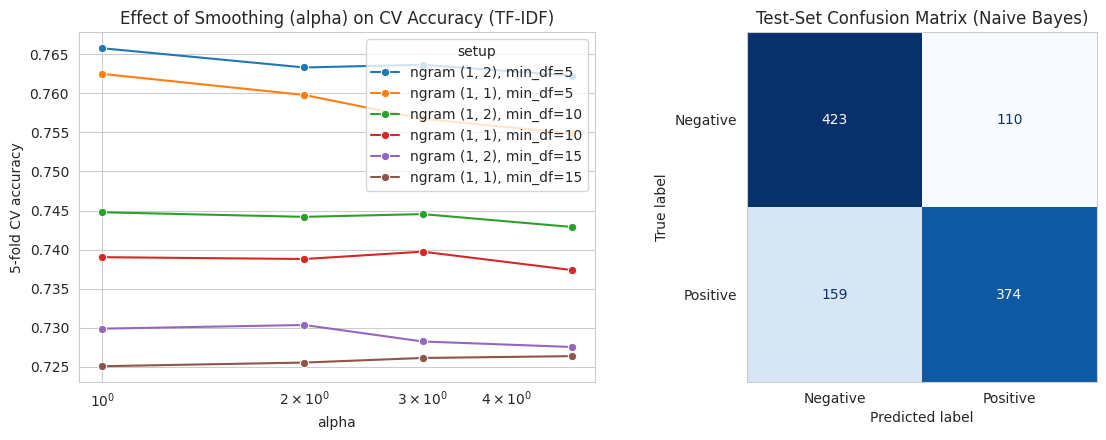

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: effect of alpha for each n-gram / min_df setup (TF-IDF features, cross-validation accuracy)
plot_df = results_df[results_df["feature_type"] == "Tfidf"].copy()
plot_df["setup"] = "ngram " + plot_df["ngram_range"].astype(str) + ", min_df=" + plot_df["min_df"].astype(str)
sns.lineplot(data=plot_df, x="alpha", y="cv_accuracy", hue="setup", marker="o", ax=axes[0])
axes[0].set_xscale("log")
axes[0].set_title("Effect of Smoothing (alpha) on CV Accuracy (TF-IDF)")
axes[0].set_ylabel("5-fold CV accuracy")

# Right: confusion matrix on the test set
cm = confusion_matrix(y_test, test_pred)
ConfusionMatrixDisplay(cm, display_labels=["Negative", "Positive"]).plot(ax=axes[1], cmap="Blues", colorbar=False)
axes[1].set_title("Test-Set Confusion Matrix (Naive Bayes)")
axes[1].grid(False)

plt.tight_layout()
plt.show()

### Which words drive the predictions?

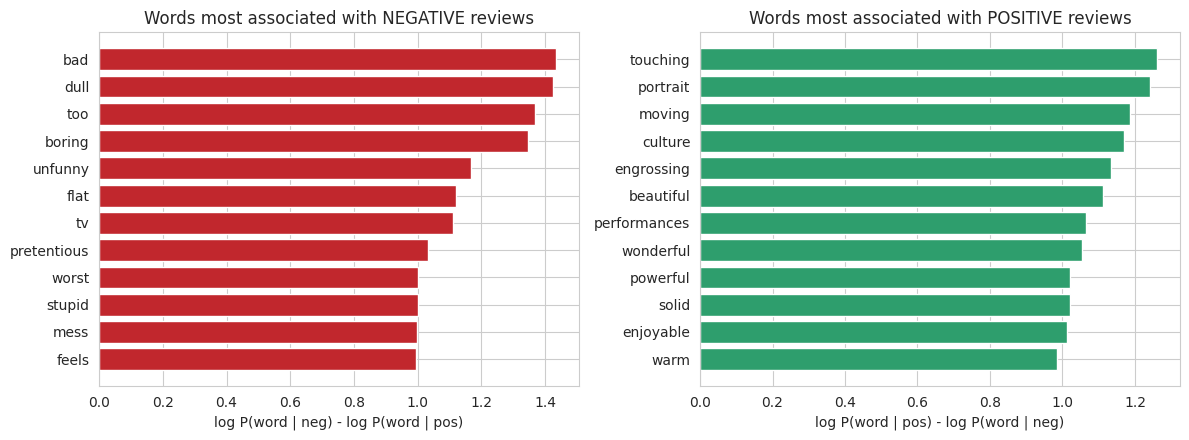

In [ ]:
vec_best = best_model.named_steps["vec"]
nb_best  = best_model.named_steps["clf"]
words = np.array(vec_best.get_feature_names_out())
log_ratio = nb_best.feature_log_prob_[1] - nb_best.feature_log_prob_[0]   # positive minus negative

top_pos = np.argsort(log_ratio)[-12:][::-1]
top_neg = np.argsort(log_ratio)[:12]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].barh(words[top_neg][::-1], -log_ratio[top_neg][::-1], color="#C1272D")
axes[0].set_title("Words most associated with NEGATIVE reviews")
axes[0].set_xlabel("log P(word | neg) - log P(word | pos)")
axes[1].barh(words[top_pos][::-1], log_ratio[top_pos][::-1], color="#2E9E6D")
axes[1].set_title("Words most associated with POSITIVE reviews")
axes[1].set_xlabel("log P(word | pos) - log P(word | neg)")
plt.tight_layout()
plt.show()

## Overfitting Check: Train vs. Test Performance

In [ ]:
train_acc = accuracy_score(y_train, best_model.predict(X_train_text))
test_acc  = accuracy_score(y_test, test_pred)
gap = train_acc - test_acc

print(f"Train accuracy: {train_acc:.4f}")
print(f"Test accuracy:  {test_acc:.4f}")
print(f"Train-test gap: {gap:.4f}  ({gap*100:.1f} percentage points)")

if gap > 0.10:
    print("Gap exceeds 10 points -- likely overfitting. Increase alpha or reduce the vocabulary (higher min_df).")
elif gap > 0.05:
    print("Moderate gap (5-10 points) -- some overfitting; worth monitoring.")
else:
    print("Gap is small -- no strong evidence of overfitting.")

Train accuracy: 0.7790
Test accuracy:  0.7477
Train-test gap: 0.0314  (3.1 percentage points)
Gap is small -- no strong evidence of overfitting.


In [ ]:
# Same diagnostic across the other varieties, to show how smoothing controls overfitting.
# The accuracy-vs-overfitting trade-off, shown openly. Only cross-validation numbers are used here
# (the test set plays no part in comparing varieties).
cols = ["feature_type", "ngram_range", "min_df", "alpha", "cv_accuracy", "train_accuracy", "cv_train_gap"]
print("Highest-CV-accuracy variety (not selected -- gap too large):")
print(unconstrained.to_frame().T[cols].to_string(index=False))
print()
print("SELECTED variety (best CV accuracy with gap under the limit):")
print(selected.to_frame().T[cols].to_string(index=False))
print()
print("Variety with the smallest train-vs-CV gap:")
print(results_df.sort_values("cv_train_gap").iloc[[0]][cols].to_string(index=False))
print()
print(f"Cost of the overfitting rule: CV accuracy {selected['cv_accuracy']:.4f} vs. "
      f"{unconstrained['cv_accuracy']:.4f} unconstrained "
      f"({(unconstrained['cv_accuracy']-selected['cv_accuracy'])*100:.1f} points), "
      f"gap {selected['cv_train_gap']*100:.1f} pp vs. {unconstrained['cv_train_gap']*100:.1f} pp.")

Highest-CV-accuracy variety (not selected -- gap too large):
feature_type ngram_range min_df alpha cv_accuracy train_accuracy cv_train_gap
       Tfidf      (1, 2)      5   1.0    0.765768       0.877667     0.111899

SELECTED variety (best CV accuracy with gap under the limit):
feature_type ngram_range min_df alpha cv_accuracy train_accuracy cv_train_gap
       Tfidf      (1, 1)     15   5.0    0.726377       0.772392     0.046014

Variety with the smallest train-vs-CV gap:
feature_type ngram_range  min_df  alpha  cv_accuracy  train_accuracy  cv_train_gap
       Tfidf      (1, 1)      15    5.0     0.726377        0.772392      0.046014

Cost of the overfitting rule: CV accuracy 0.7264 vs. 0.7658 unconstrained (3.9 points), gap 4.6 pp vs. 11.2 pp.


## 5. Comparison Across Varieties & Conclusion

In [ ]:
best_row = selected
worst_row = results_df.iloc[-1]
is_uni = results_df["ngram_range"].apply(lambda t: tuple(t) == (1, 1))
uni = results_df[is_uni]["cv_accuracy"].max()
bi  = results_df[~is_uni]["cv_accuracy"].max()
cnt = results_df[results_df["feature_type"] == "Count"]["cv_accuracy"].max()
tfi = results_df[results_df["feature_type"] == "Tfidf"]["cv_accuracy"].max()

print(f"Varieties tried: {len(results_df)}  (cross-validation accuracy range: "
      f"{worst_row['cv_accuracy']:.4f} to {best_row['cv_accuracy']:.4f})")
print(f"Selected variety: {best_row['feature_type']} features, ngram_range={best_row['ngram_range']}, min_df={best_row['min_df']}, alpha={best_row['alpha']}")
print(f"Best unigram-only CV accuracy: {uni:.4f}  vs. best uni+bigram: {bi:.4f}")
print(f"Best Count CV accuracy:        {cnt:.4f}  vs. best TF-IDF:      {tfi:.4f}")
print(f"Final test accuracy: {test_acc:.4f}   |   train-test gap: {gap*100:.1f} pp")

Varieties tried: 48  (cross-validation accuracy range: 0.7181 to 0.7264)
Selected variety: Tfidf features, ngram_range=(1, 1), min_df=15, alpha=5.0
Best unigram-only CV accuracy: 0.7625  vs. best uni+bigram: 0.7658
Best Count CV accuracy:        0.7637  vs. best TF-IDF:      0.7658
Final test accuracy: 0.7477   |   train-test gap: 3.1 pp
